In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf
from dieboldmariano import dm_test

from de_lu_epf.plots.utils import update_matplotlib_params
from de_lu_epf.plots.predictions import plot_metric_barplot
from de_lu_epf.models.predicting import get_all_set_preds

In [2]:
update_matplotlib_params()

In [3]:
df = pd.read_parquet("../data/processed/processed.parquet")
df_train = df[(df.index.year >= 2019) & (df.index.year < 2024)]
print(df_train.shape)
df_train.head()

(43824, 14)


,precipitation,temperature,relative_humidity,price,load,renewable_share_of_load,renewable_share_of_generation,sum_cbet,24_rmean_price,168_rmean_price,672_rmean_price,24_rvar_price,168_rvar_price,672_rvar_price
datetime,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,0.250,7.05,92.50,10.07,52750.6,30.6,31.7,-0.605,52.097500,46.054583,48.899777,191.727489,423.445304,431.477251
2019-01-01 01:00:00+00:00,0.100,7.25,91.25,-4.08,51944.2,31.7,32.2,-1.946,49.914167,46.030536,48.847485,323.346417,425.772661,435.183304
2019-01-01 02:00:00+00:00,0.075,7.25,92.25,-9.91,53075.2,33.1,33.3,-1.017,47.589167,45.924286,48.791116,472.607373,435.811931,439.675759
2019-01-01 03:00:00+00:00,0.050,7.05,94.00,-7.41,56323.7,34.1,34.5,-1.964,45.385833,45.805893,48.732649,598.864121,446.133314,443.953378
2019-01-01 04:00:00+00:00,0.000,7.15,93.50,-12.55,56937.8,38.0,37.8,-3.168,42.900000,45.726905,48.654643,738.224261,454.346633,449.427190


/var/folders/j7/fswh0x992tzfxgs898w7vv9w0000gn/T/ipykernel_66356/1977073144.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=xticklabels, size=24)


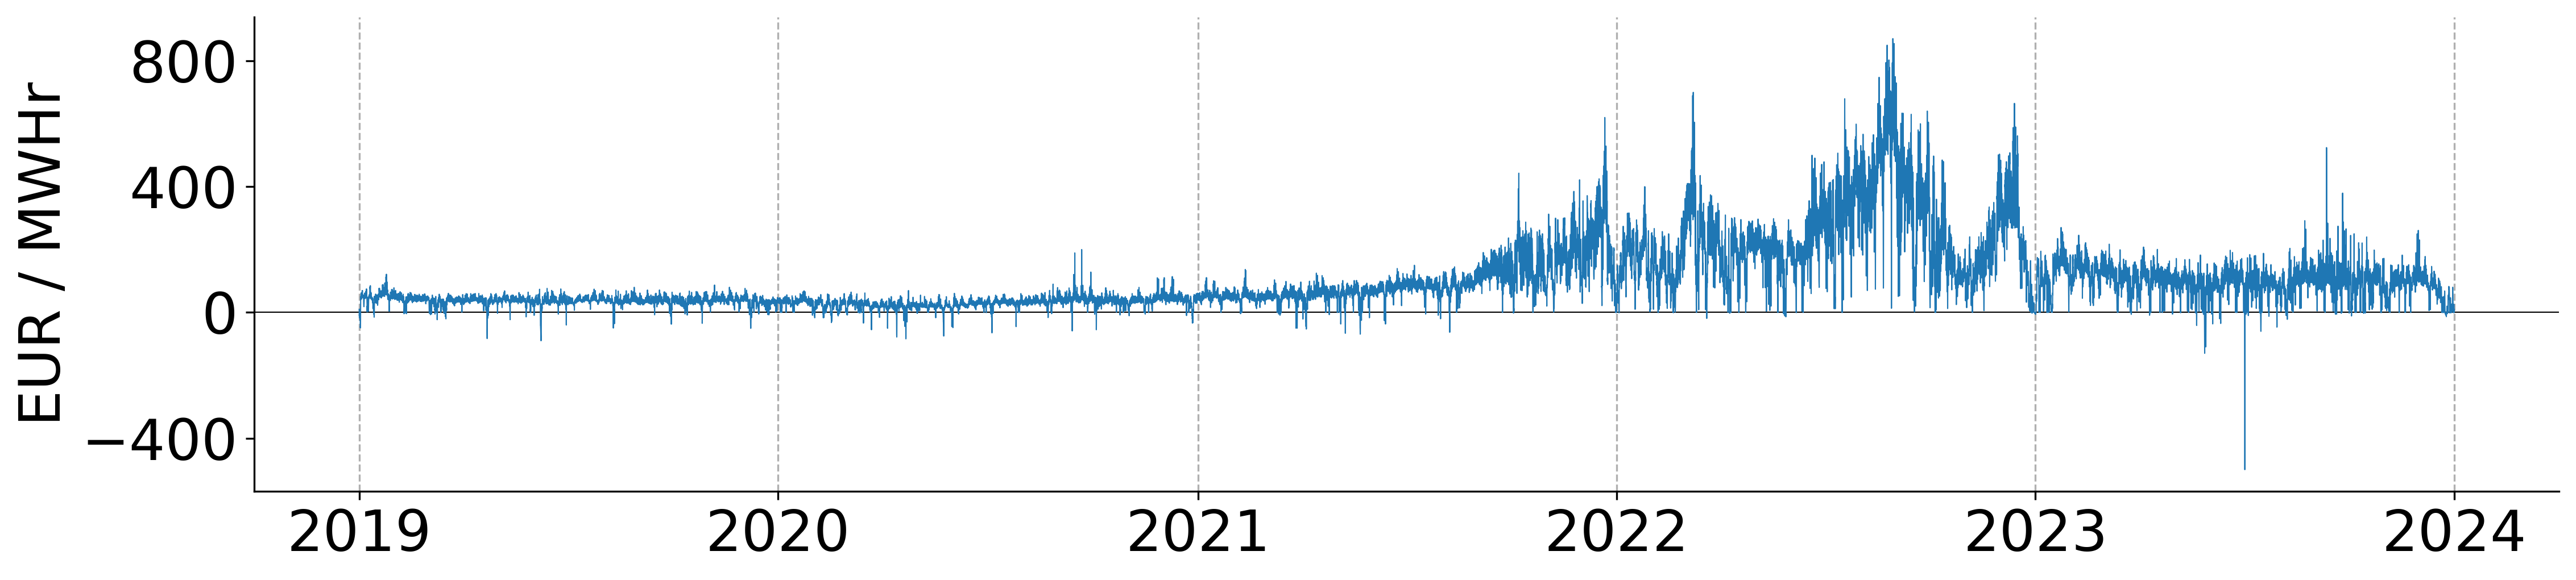

In [4]:
fig, ax = plt.subplots(figsize=(15.2, 3.5), dpi=300)

ax.plot(df_train.index, df_train["price"], c="tab:blue", linewidth=0.5)

ax.axhline(0, color="black", zorder=0, linewidth=0.5)
ax.grid(axis="x", linestyle="--")

xticklabels = ax.get_xticklabels()
ax.set_xticklabels(labels=xticklabels, size=24)

ax.set_yticks([-400, 0, 400, 800])
yticklabels = ax.get_yticklabels()
ax.set_yticklabels(labels=yticklabels, size=24)
ax.set_ylabel("EUR / MWHr", size=24)

# ax.set_title(
#     "Hourly Electricity Prices in the Train Set (2019-2024)", size=24, fontweight="bold"
# )

ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig("../../../mures_presentation/data_electricity_prices.svg")
plt.show()

In [5]:
df_vmd = pd.read_parquet("../data/processed/hybrid/test.parquet")
print(df_vmd.shape)
df_vmd.head()

(8783, 20)


,precipitation,temperature,relative_humidity,price,load,renewable_share_of_load,renewable_share_of_generation,sum_cbet,24_rmean_price,168_rmean_price,672_rmean_price,24_rvar_price,168_rvar_price,672_rvar_price,imf1,imf2,imf3,imf4,imf5,imf_resid
datetime,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,0.000,8.65,67.75,0.01,48174.6,96.1,83.4,-7.422,7.832083,20.772500,62.104687,56.557574,676.280960,1941.274204,10.453509,-5.512603,-0.441802,-0.674397,0.223593,-4.038298
2024-01-01 01:00:00+00:00,0.025,8.85,67.00,0.00,48362.4,90.7,81.2,-7.465,7.665417,20.836845,61.973705,58.557139,672.887828,1946.004249,10.453225,-5.513011,-0.442606,-0.675983,0.219021,-4.040646
2024-01-01 02:00:00+00:00,0.000,8.55,67.50,-0.01,49452.1,87.2,79.7,-7.074,7.652083,20.911131,61.846637,58.766078,668.833847,1950.897356,10.504494,-4.222000,0.486210,1.008028,-0.557810,-7.228923
2024-01-01 03:00:00+00:00,0.025,8.20,71.50,-0.03,52277.7,81.1,75.1,-7.147,7.626667,20.990536,61.718869,59.156710,664.416337,1955.729764,10.635000,-1.891152,0.625967,0.172186,0.595889,-10.167889
2024-01-01 04:00:00+00:00,0.075,7.95,75.50,-0.02,53096.3,81.7,75.1,-7.643,7.572500,21.050774,61.581875,59.944576,661.253000,1960.021427,10.871205,0.959713,-0.559424,-1.211574,-0.436143,-9.643777


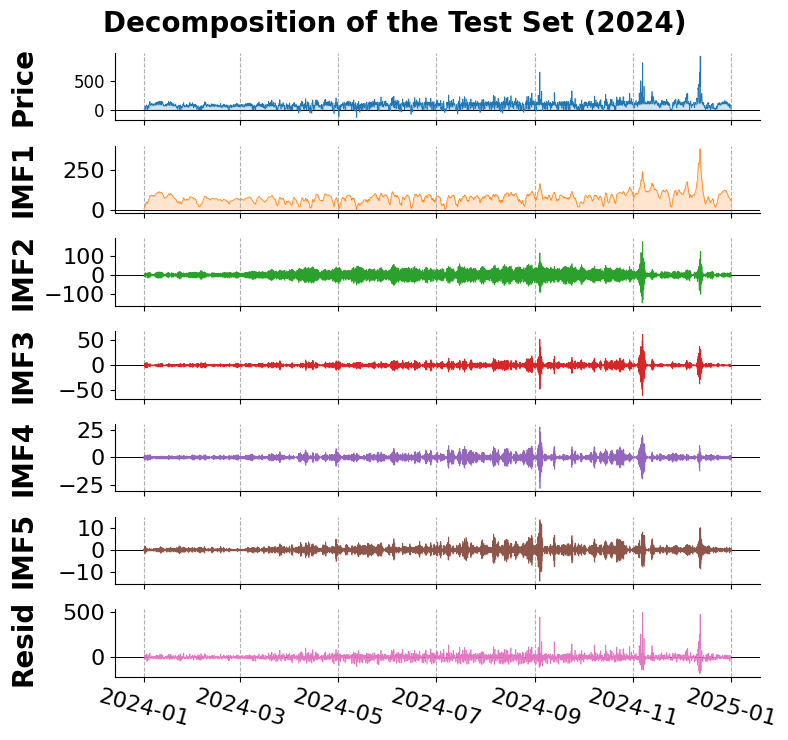

In [6]:
fig, axes = plt.subplots(7, sharex=True, figsize=(8, 7.5))
colors = plt.colormaps["tab10"].colors

ax = axes[0]
ax.axhline(0, linewidth=0.7, color="black")
ax.plot(df_vmd.index, df_vmd["price"], linewidth=0.5, c=colors[0])
ax.fill_between(df_vmd.index, df_vmd["price"], color=colors[0], alpha=0.2)
ax.grid(axis="x", linestyle="--")
ax.set_ylabel("Price", fontsize=20, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=12)

for i, (col, ylab) in enumerate(
    zip(
        ["imf1", "imf2", "imf3", "imf4", "imf5", "imf_resid"],
        ["IMF1", "IMF2", "IMF3", "IMF4", "IMF5", "Resid"],
    )
):
    ax = axes[i + 1]
    ax.axhline(0, linewidth=0.7, color="black")
    ax.plot(df_vmd.index, df_vmd[col], linewidth=0.5, c=colors[i + 1])
    ax.fill_between(df_vmd.index, df_vmd[col], color=colors[i + 1], alpha=0.2)
    ax.grid(axis="x", linestyle="--")
    ax.set_ylabel(ylab, fontsize=20, fontweight="bold")
    ax.tick_params(axis="x", labelsize=16, rotation=-15)
    ax.tick_params(axis="y", labelsize=16)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Decomposition of the Test Set (2024)", fontsize=20, fontweight="bold")
fig.tight_layout()
fig.align_ylabels()
fig.savefig("../../../mures_presentation/methods_vmd.png", dpi=1_000)
plt.show()

In [7]:
df_vp = df_train.copy(deep=True)

days_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
months_order = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
hours_order = [f"{h:02d}:00" for h in range(24)]

df_vp["day_of_week"] = pd.Categorical(
    df_vp.index.strftime("%a"), categories=days_order, ordered=True
)
df_vp["month"] = pd.Categorical(
    df_vp.index.strftime("%b"), categories=months_order, ordered=True
)
df_vp["hour_of_day"] = pd.Categorical(
    df_vp.index.strftime("%H:00"), categories=hours_order, ordered=True
)

df_vp.head()

,precipitation,temperature,relative_humidity,price,load,renewable_share_of_load,renewable_share_of_generation,sum_cbet,24_rmean_price,168_rmean_price,672_rmean_price,24_rvar_price,168_rvar_price,672_rvar_price,day_of_week,month,hour_of_day
datetime,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,0.250,7.05,92.50,10.07,52750.6,30.6,31.7,-0.605,52.097500,46.054583,48.899777,191.727489,423.445304,431.477251,Tue,Jan,00:00
2019-01-01 01:00:00+00:00,0.100,7.25,91.25,-4.08,51944.2,31.7,32.2,-1.946,49.914167,46.030536,48.847485,323.346417,425.772661,435.183304,Tue,Jan,01:00
2019-01-01 02:00:00+00:00,0.075,7.25,92.25,-9.91,53075.2,33.1,33.3,-1.017,47.589167,45.924286,48.791116,472.607373,435.811931,439.675759,Tue,Jan,02:00
2019-01-01 03:00:00+00:00,0.050,7.05,94.00,-7.41,56323.7,34.1,34.5,-1.964,45.385833,45.805893,48.732649,598.864121,446.133314,443.953378,Tue,Jan,03:00
2019-01-01 04:00:00+00:00,0.000,7.15,93.50,-12.55,56937.8,38.0,37.8,-3.168,42.900000,45.726905,48.654643,738.224261,454.346633,449.427190,Tue,Jan,04:00


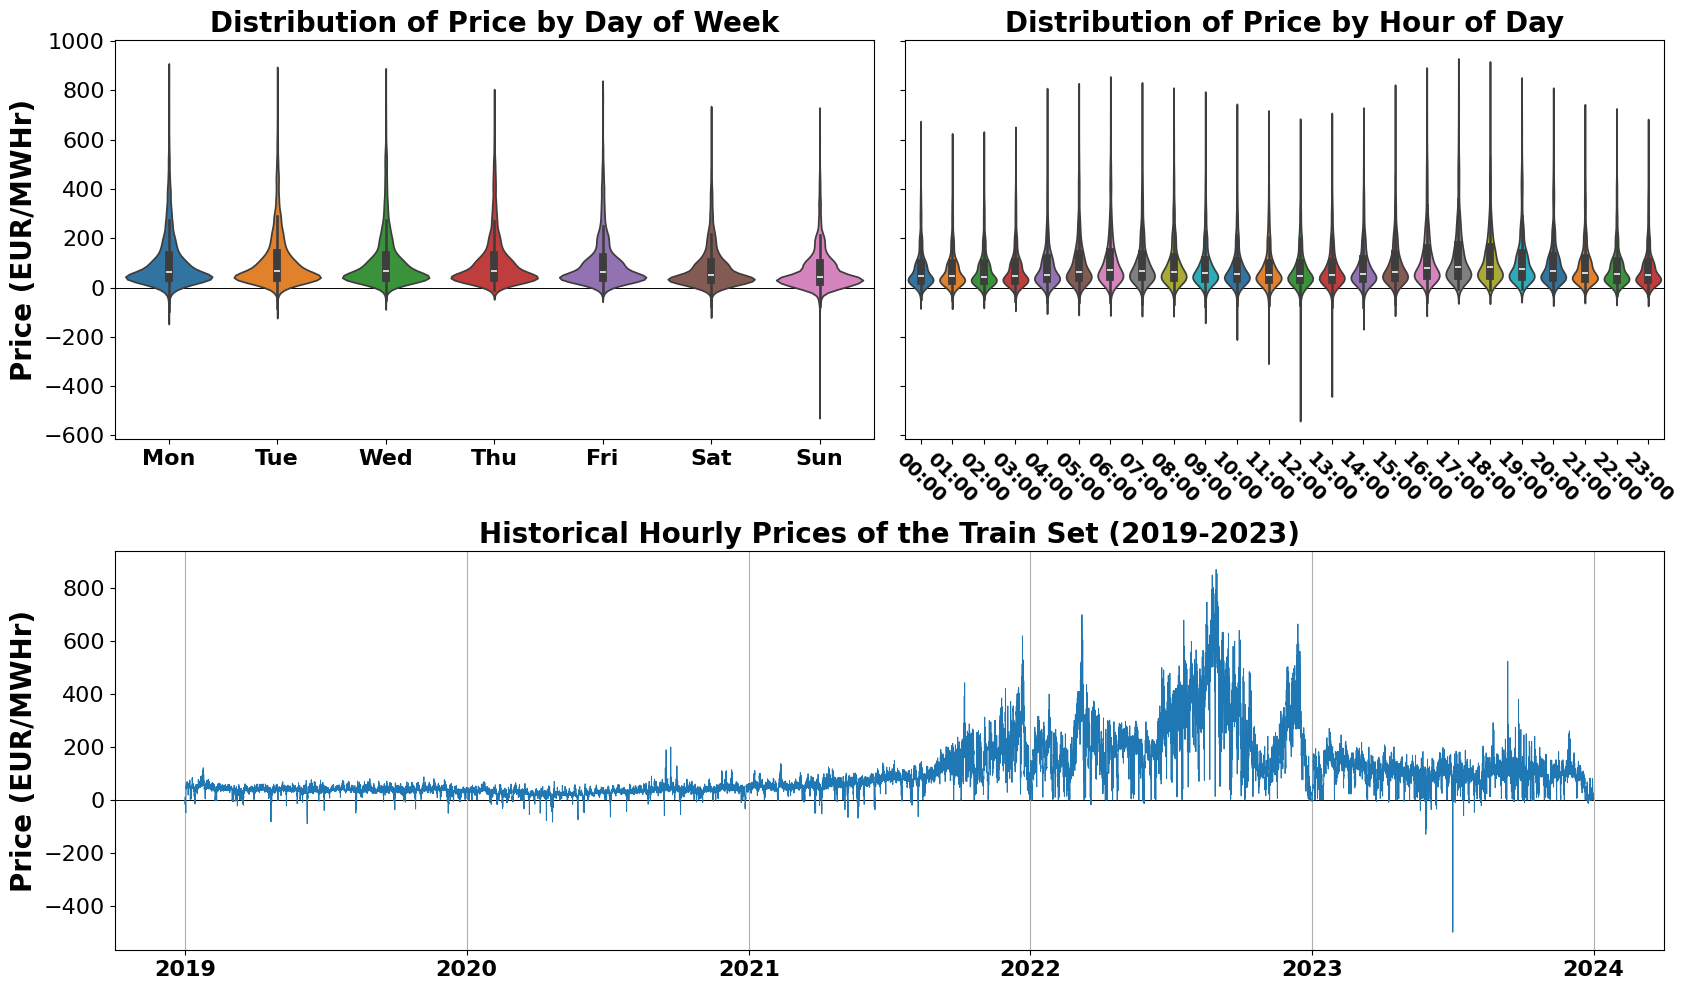

In [8]:
fig = plt.figure(figsize=(17, 10))
gs = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, :])

########################################################################################################################

ax0.axhline(0, color="black", linewidth=0.7, zorder=0)
sns.violinplot(
    data=df_vp, x="day_of_week", y="price", hue="day_of_week", palette="tab10", ax=ax0
)

ax0.set_xlabel(None)
ax0.set_ylabel("Price (EUR/MWHr)", fontsize=20, fontweight="bold")
ax0.set_title("Distribution of Price by Day of Week", fontsize=20, fontweight="bold")

for label in ax0.get_xticklabels():
    label.set_fontweight("bold")

for label in ax0.get_xticklabels() + ax0.get_yticklabels():
    label.set_fontsize(16)

########################################################################################################################

ax1.axhline(0, color="black", linewidth=0.7, zorder=0)
sns.violinplot(
    data=df_vp, x="hour_of_day", y="price", hue="hour_of_day", palette="tab10", ax=ax1
)

ax1.set_xlabel(None)
ax1.set_ylabel(None)
ax1.set_yticklabels([])
ax1.set_title("Distribution of Price by Hour of Day", fontsize=20, fontweight="bold")

for label in ax1.get_xticklabels():
    label.set_fontweight("bold")
    label.set_fontsize(14)

ymin = min(ax0.get_ylim()[0], ax1.get_ylim()[0])
ymax = max(ax0.get_ylim()[1], ax1.get_ylim()[1])

ax1.tick_params(axis="x", rotation=-45)

ax0.set_ylim(ymin, ymax)
ax1.set_ylim(ymin, ymax)

########################################################################################################################

ax2.axhline(0, color="black", linewidth=0.7, zorder=0)
ax2.plot(df_vp.index, df_vp["price"], linewidth=0.7, c="tab:blue")

for label in ax2.get_xticklabels():
    label.set_fontweight("bold")

for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_fontsize(16)

ax2.set_title(
    "Historical Hourly Prices of the Train Set (2019-2023)",
    fontsize=20,
    fontweight="bold",
)
ax2.set_ylabel("Price (EUR/MWHr)", fontsize=20, fontweight="bold")

ax2.grid(axis="x")

########################################################################################################################

fig.tight_layout()
fig.savefig("../../../mures_presentation/data_overview.svg")
plt.show()

In [9]:
df_test = pd.read_parquet("../data/processed/hybrid/test.parquet")
print(df_test.shape)
df_test.head()

(8783, 20)


,precipitation,temperature,relative_humidity,price,load,renewable_share_of_load,renewable_share_of_generation,sum_cbet,24_rmean_price,168_rmean_price,672_rmean_price,24_rvar_price,168_rvar_price,672_rvar_price,imf1,imf2,imf3,imf4,imf5,imf_resid
datetime,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,0.000,8.65,67.75,0.01,48174.6,96.1,83.4,-7.422,7.832083,20.772500,62.104687,56.557574,676.280960,1941.274204,10.453509,-5.512603,-0.441802,-0.674397,0.223593,-4.038298
2024-01-01 01:00:00+00:00,0.025,8.85,67.00,0.00,48362.4,90.7,81.2,-7.465,7.665417,20.836845,61.973705,58.557139,672.887828,1946.004249,10.453225,-5.513011,-0.442606,-0.675983,0.219021,-4.040646
2024-01-01 02:00:00+00:00,0.000,8.55,67.50,-0.01,49452.1,87.2,79.7,-7.074,7.652083,20.911131,61.846637,58.766078,668.833847,1950.897356,10.504494,-4.222000,0.486210,1.008028,-0.557810,-7.228923
2024-01-01 03:00:00+00:00,0.025,8.20,71.50,-0.03,52277.7,81.1,75.1,-7.147,7.626667,20.990536,61.718869,59.156710,664.416337,1955.729764,10.635000,-1.891152,0.625967,0.172186,0.595889,-10.167889
2024-01-01 04:00:00+00:00,0.075,7.95,75.50,-0.02,53096.3,81.7,75.1,-7.643,7.572500,21.050774,61.581875,59.944576,661.253000,1960.021427,10.871205,0.959713,-0.559424,-1.211574,-0.436143,-9.643777


In [10]:
df_preds = get_all_set_preds(set="test")
print(df_preds.shape)
display(df_preds.head())

idx = df_preds.index
actual_series = df_test.loc[idx, "price"].copy(deep=True)
actual_series

(8424, 18)


,TCN-LSTM-MHA,LSTM,TCN-MHA,TCN-LSTM,LSTM-MHA,TCN,LGBMR,SVR,EN,LR,XGBR,RFR,VLM,VTLM,VTL,VL,VTM,VT
2024-01-15 00:00:00+00:00,85.635986,64.361702,49.975132,86.911194,60.002365,56.189030,64.034898,69.872790,66.150575,60.345978,65.800911,52.316024,60.351650,81.532913,71.898659,71.358849,47.886425,58.010010
2024-01-15 01:00:00+00:00,82.930786,61.582893,57.506824,82.803085,64.514931,61.411076,80.493879,80.064681,74.781609,73.415494,76.205597,72.587055,65.784355,70.552505,70.255875,59.775993,45.159218,52.030785
2024-01-15 02:00:00+00:00,74.397888,60.887669,50.554001,82.429047,54.754780,56.350662,77.779493,71.262688,75.733839,91.097048,77.397949,72.939104,60.336590,63.649128,69.645569,64.298218,44.932125,45.442017
2024-01-15 03:00:00+00:00,81.599876,64.935707,54.122944,86.263184,65.737572,58.150272,80.942948,69.654146,77.651984,85.746895,77.106499,78.039593,51.500072,66.058044,71.978088,69.949570,44.249771,57.057079
2024-01-15 04:00:00+00:00,96.885139,77.851952,55.716808,89.628044,69.604370,69.197990,79.584199,70.181419,75.652554,74.679806,80.055756,79.136040,56.652103,75.910187,86.092880,70.513359,51.182644,58.935963


2024-01-15 00:00:00+00:00    65.00
2024-01-15 01:00:00+00:00    63.94
2024-01-15 02:00:00+00:00    62.04
2024-01-15 03:00:00+00:00    62.04
2024-01-15 04:00:00+00:00    69.25
                             ...  
2024-12-30 19:00:00+00:00    74.83
2024-12-30 20:00:00+00:00    68.02
2024-12-30 21:00:00+00:00    67.26
2024-12-30 22:00:00+00:00    35.66
2024-12-30 23:00:00+00:00    50.49
Name: price, Length: 8424, dtype: float64

In [11]:
def mean_directional_accuracy(y_true, y_pred):
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)

    mask = true_diff != 0
    return np.mean(np.sign(true_diff[mask]) == np.sign(pred_diff[mask]))

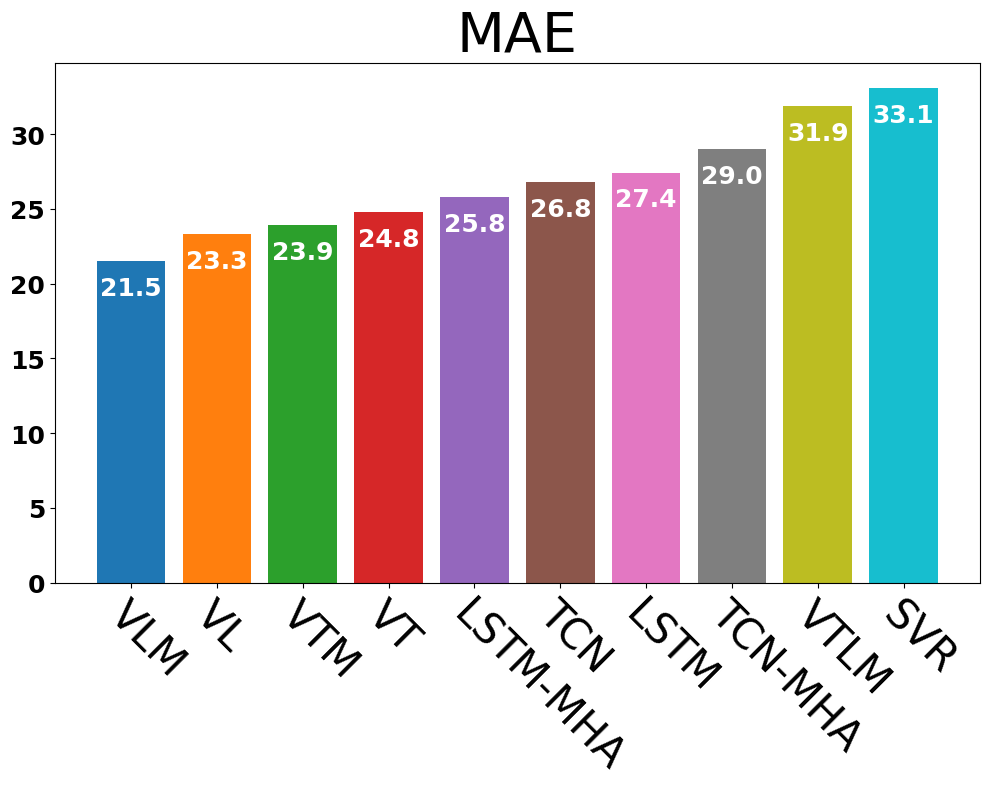

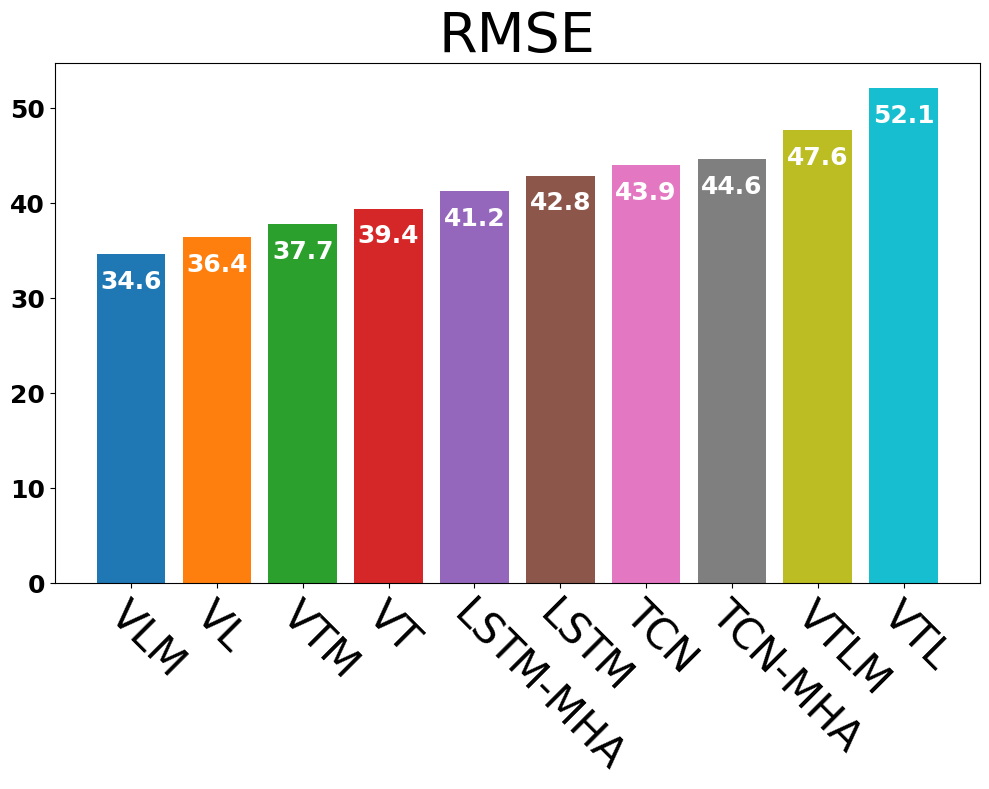

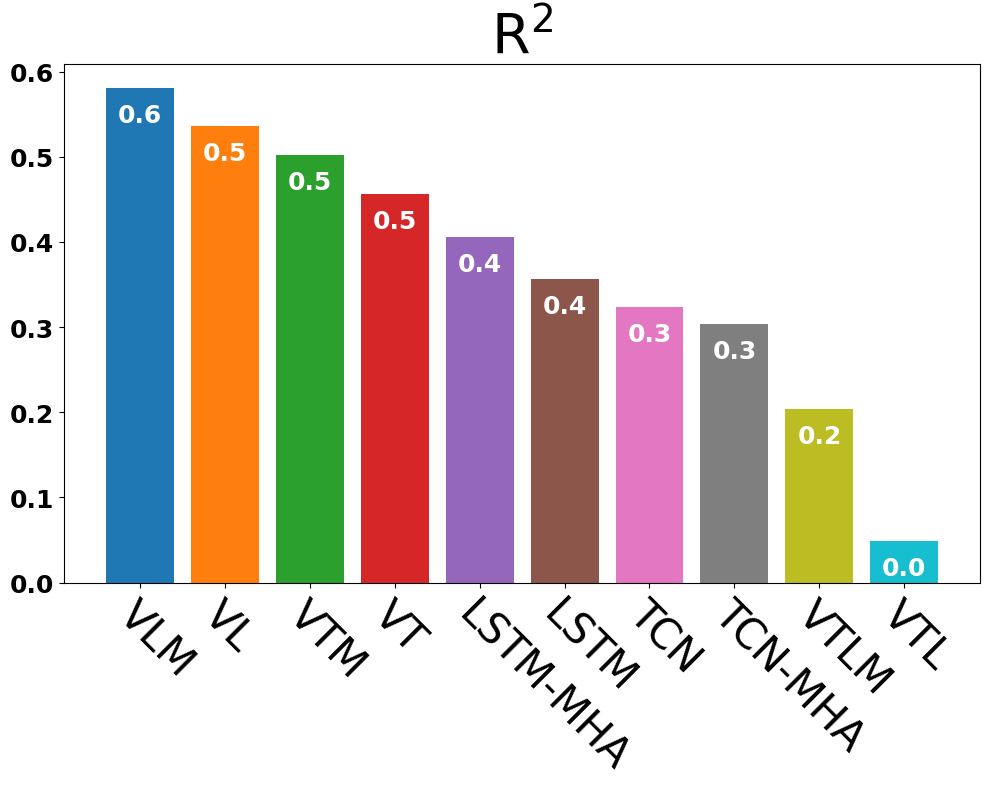

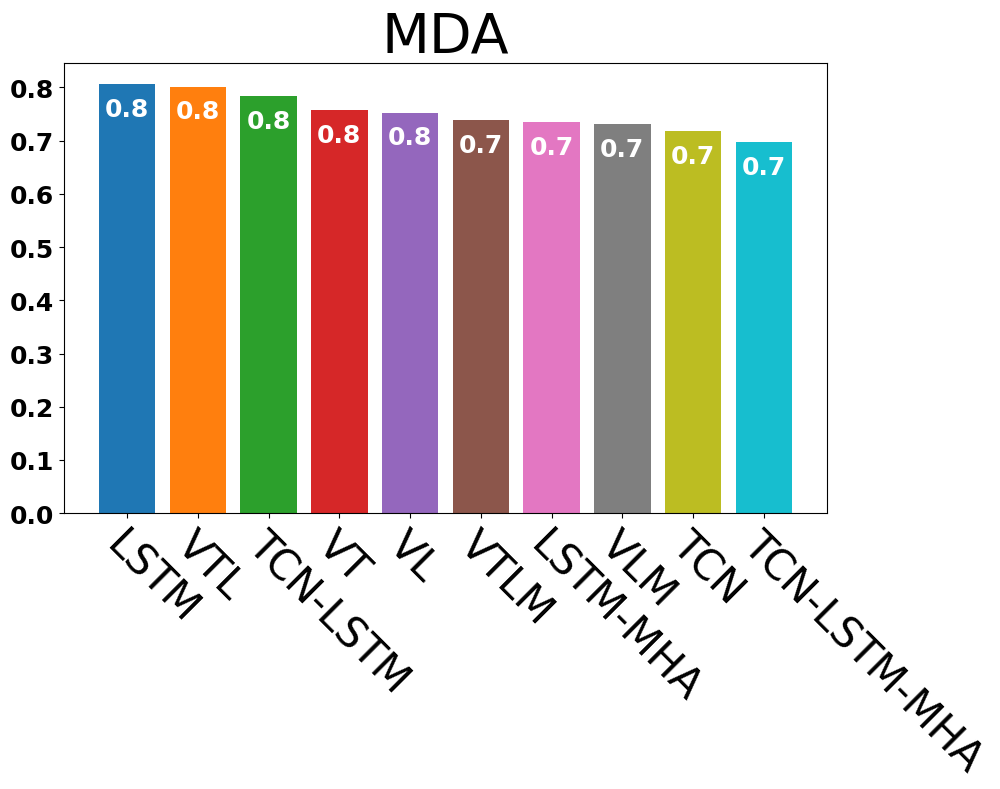

In [12]:
for metric, asc, title, inline in zip(
    [mean_absolute_error, root_mean_squared_error, r2_score, mean_directional_accuracy],
    [True, True, False, False],
    ["MAE", "RMSE", r"$\text{R}^2$", "MDA"],
    [False, False, False, False],
):
    fig, ax = plot_metric_barplot(
        actual_series=actual_series,
        pred_df=df_preds,
        metric=metric,
        figsize=(10, 8),
        inline_text=inline,
        ascending=asc,
    )

    ax.set_title(title, fontsize=40)
    ax.set_ylabel(None)
    ax.set_xlabel(None)

    ax.tick_params(
        axis="x",
        labelsize=30,
    )
    for label in ax.get_xticklabels():
        label.set_ha("left")
        label.set_rotation_mode("anchor")

    fig.tight_layout()
    fig.savefig(f"../../../mures_presentation/test_{title.lower()}.svg")

In [13]:
abs_err = (df_preds.sub(actual_series, axis=0)).abs()
df_dmae = abs_err.resample("D").mean().div(actual_series.resample("D").mean(), axis=0)
df_dmae = df_dmae.stack().reset_index(name="DMAE").rename(columns={"level_1": "Model"})
df_dmae = df_dmae.rename(columns={"level_0": "datetime"}).set_index("datetime")
print(df_dmae.shape)
df_dmae.head()

(6318, 2)


,Model,DMAE
datetime,,
2024-01-15 00:00:00+00:00,TCN-LSTM-MHA,0.109852
2024-01-15 00:00:00+00:00,LSTM,0.083838
2024-01-15 00:00:00+00:00,TCN-MHA,0.292713
2024-01-15 00:00:00+00:00,TCN-LSTM,0.104677
2024-01-15 00:00:00+00:00,LSTM-MHA,0.058596


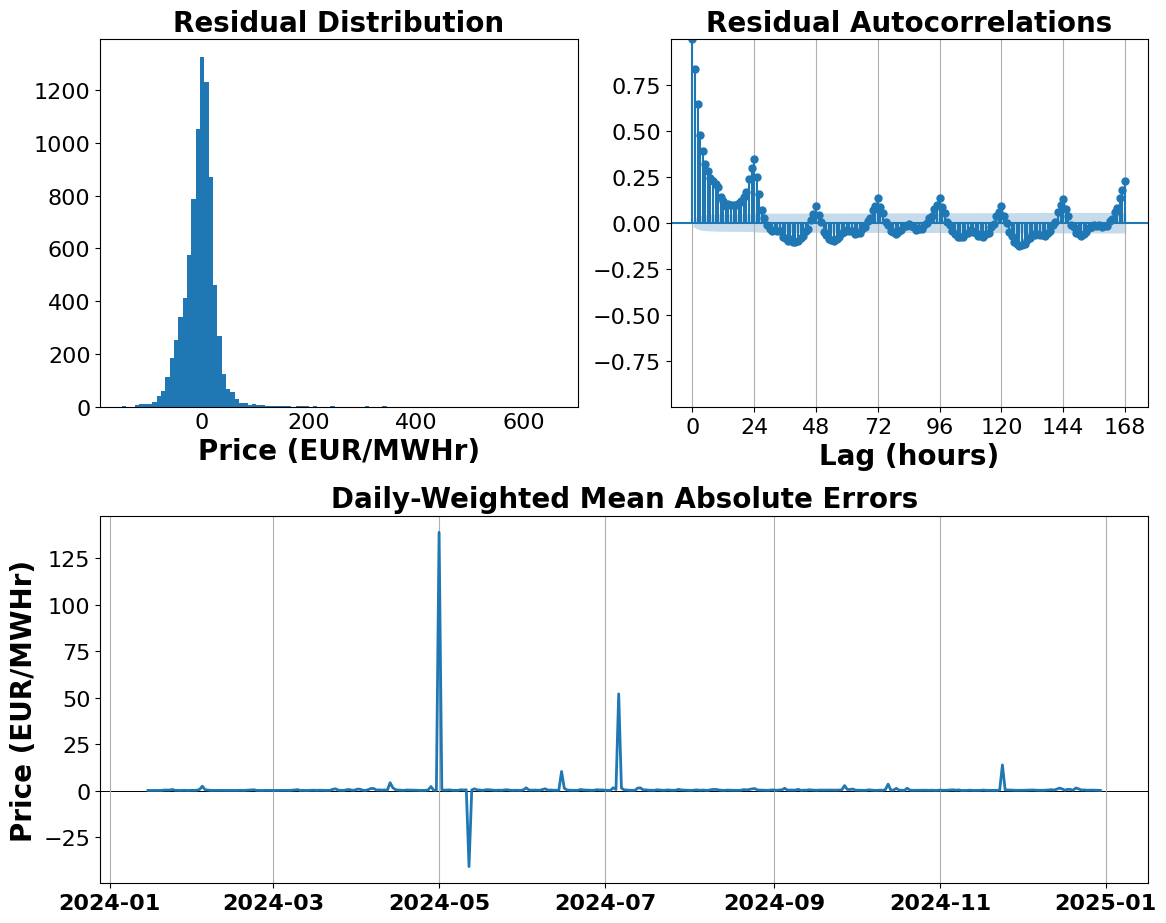

In [14]:
fig = plt.figure(figsize=(5.89 * 2, 4.67 * 2))
gs = fig.add_gridspec(2, 2)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, :])

ax0.axhline(0, color="black", linewidth=0.7, zorder=-1)
ax0.hist(actual_series - df_preds["VLM"], bins=100, color="tab:blue")
ax0.set_xlabel("Price (EUR/MWHr)", fontsize=20, fontweight="bold")
ax0.tick_params(axis="x", size=0)
ax0.set_title("Residual Distribution", fontsize=20, fontweight="bold")
ax0.tick_params(axis="both", labelsize=16)

plot_acf(ax=ax1, x=actual_series - df_preds["VLM"], lags=24 * 7)
ax1.set_title("Residual Autocorrelations", fontsize=20, fontweight="bold")
ax1.set_xlabel("Lag (hours)", fontweight="bold", fontsize=20)
ax1.set_xticks([_ for _ in range(0, 24 * 7 + 1, 24)])
ax1.set_yticks([_ for _ in np.arange(-0.75, 1.0, 0.25)])
ax1.tick_params(axis="both", labelsize=16)
ax1.grid(axis="x")

ax2.axhline(0, color="black", linewidth=0.7, zorder=-1)
sns.lineplot(
    data=df_dmae[df_dmae["Model"] == "VLM"],
    x="datetime",
    y="DMAE",
    ax=ax2,
    linewidth=2,
    color="tab:blue",
)
ax2.set_title("Daily-Weighted Mean Absolute Errors", fontsize=20, fontweight="bold")
ax2.set_xlabel(None)
ax2.set_ylabel("Price (EUR/MWHr)", fontsize=20, fontweight="bold")
ax2.tick_params(axis="both", labelsize=16)
ax1.tick_params(axis="both", labelsize=16)
for label in ax2.get_xticklabels():
    label.set_fontweight("bold")
ax2.grid(axis="x")

# fig.suptitle(
#     "Residual Analysis of the VMD-LSTM-MHA (VLM) Model", fontsize=24, fontweight="bold"
# )
fig.tight_layout()
fig.savefig("../../../mures_presentation/vlm_residual_analysis.svg")
plt.show()

In [15]:
for metric in [
    mean_absolute_error,
    root_mean_squared_error,
    mean_directional_accuracy,
    r2_score,
]:
    print(metric.__name__)
    print(round(metric(y_true=actual_series, y_pred=df_preds["VLM"]), 3))

mean_absolute_error
21.502
root_mean_squared_error
34.604
mean_directional_accuracy
0.731
r2_score
0.58


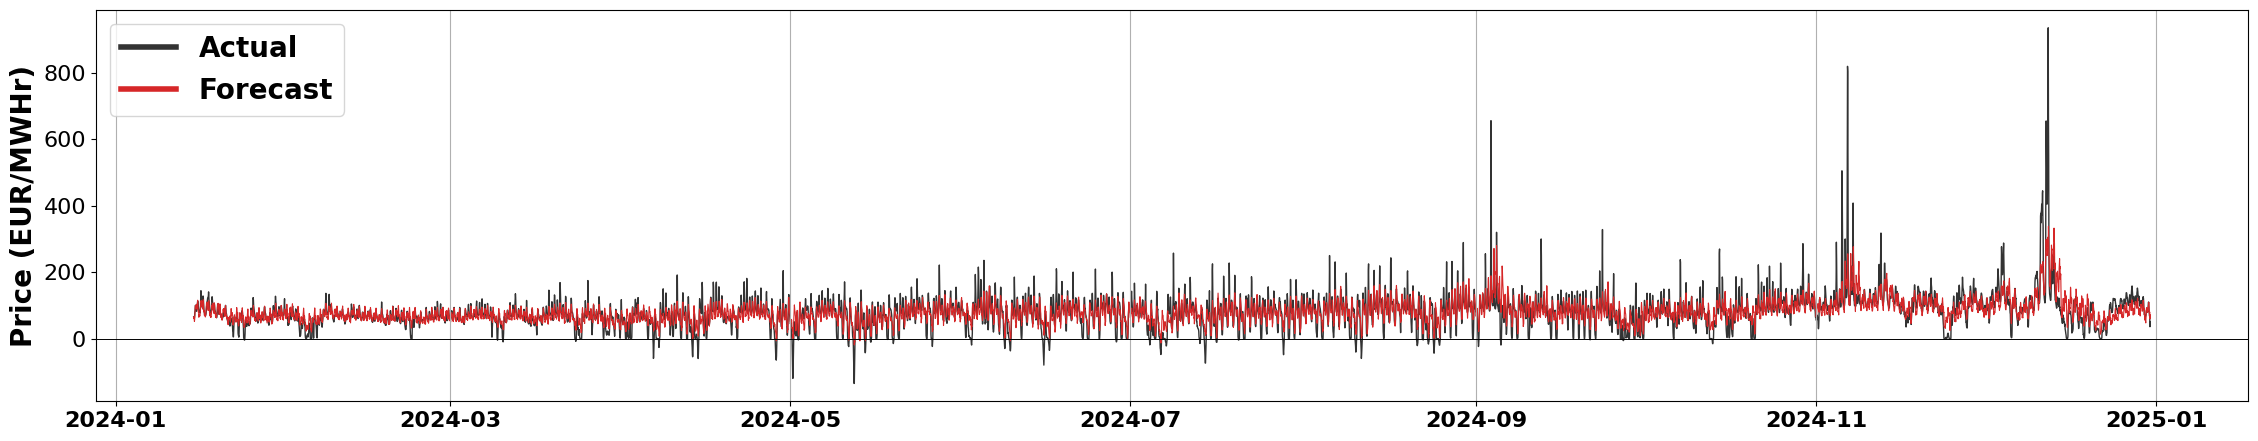

In [16]:
fig, ax = plt.subplots(figsize=(11.34 * 2, 4.51))

ax.axhline(0, color="black", linewidth=0.7)
ax.plot(
    df_preds.index,
    actual_series,
    c="black",
    alpha=0.8,
    linewidth=1,
    zorder=0,
    label="Actual",
)
ax.plot(
    df_preds.index,
    df_preds["VLM"],
    c="tab:red",
    linewidth=0.8,
    zorder=1,
    label="Forecast",
)

ax.tick_params(axis="both", labelsize=16)
for label in ax.get_xticklabels():
    label.set_fontweight("bold")
ax.set_ylabel("Price (EUR/MWHr)", fontsize=20, fontweight="bold")

legend = ax.legend(fontsize=20)
for line in legend.get_lines():
    line.set_linewidth(4)
for text in legend.get_texts():
    text.set_fontweight("bold")
ax.grid(axis="x")

fig.tight_layout()
fig.savefig("../../../mures_presentation/test_set_forecasts.svg")
plt.show()

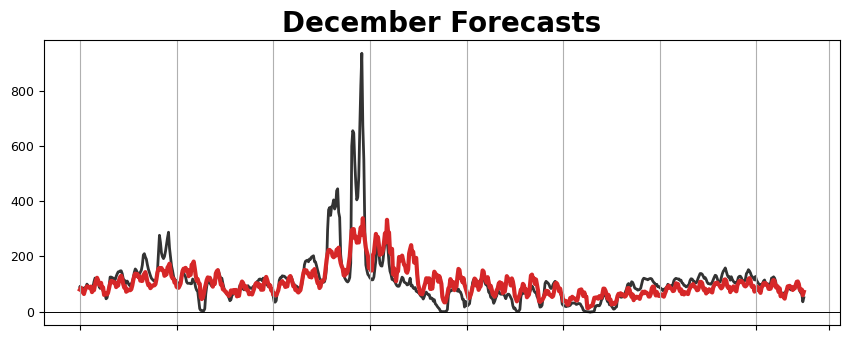

In [37]:
dt_idx = df_preds.index[df_preds.index.month == 12]
prices = df_preds.loc[dt_idx, "VLM"]
a_s = actual_series.loc[dt_idx]

fig, ax = plt.subplots(figsize=(4.3 * 2, 1.75 * 2))

ax.axhline(0, color="black", linewidth=0.7)
ax.plot(
    dt_idx,
    a_s,
    c="black",
    alpha=0.8,
    linewidth=2,
    zorder=0,
    label="Actual",
)
ax.plot(
    dt_idx,
    prices,
    c="tab:red",
    linewidth=3,
    zorder=1,
    label="Forecast",
)

ax.set_xticklabels([])
ax.set_ylabel(None)

ax.grid(axis="x")
ax.set_title("December Forecasts", fontsize=20, fontweight="bold")

fig.tight_layout()
fig.savefig("../../../mures_presentation/dec_test_set_forecasts.svg")
plt.show()

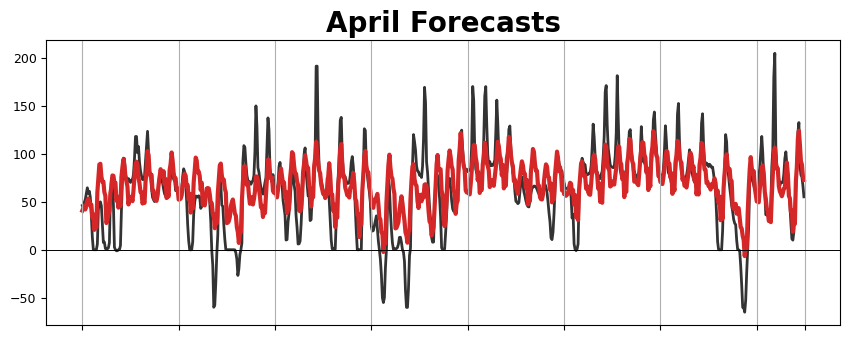

In [36]:
dt_idx = df_preds.index[df_preds.index.month == 4]
prices = df_preds.loc[dt_idx, "VLM"]
a_s = actual_series.loc[dt_idx]

fig, ax = plt.subplots(figsize=(4.3 * 2, 1.75 * 2))

ax.axhline(0, color="black", linewidth=0.7)
ax.plot(
    dt_idx,
    a_s,
    c="black",
    alpha=0.8,
    linewidth=2,
    zorder=0,
    label="Actual",
)
ax.plot(
    dt_idx,
    prices,
    c="tab:red",
    linewidth=3,
    zorder=1,
    label="Forecast",
)

ax.set_xticklabels([])
ax.set_ylabel(None)

ax.grid(axis="x")
ax.set_title("April Forecasts", fontsize=20, fontweight="bold")

fig.tight_layout()
fig.savefig("../../../mures_presentation/apr_test_set_forecasts.svg")
plt.show()

In [17]:
dm_test(
    V=actual_series,
    P1=df_preds["VLM"],
    P2=df_preds["VL"],
    h=24,
    harvey_correction=True,
    variance_estimator="bartlett",
    one_sided=True,
)

(-3.8190104906023246, 6.74749215866872e-05)